# Attention Residuals — Analysis

**Important limitation**
The current attention-residual script logs the same high-level metrics as the baseline, but it does **not** log internal attention-residual diagnostics such as source-selection weights or attention entropy. So this notebook focuses on what is available in W&B today, and explicitly flags extra metrics that would be worth logging next time.

The paper (https://arxiv.org/abs/2603.15031) motivates attention residuals as a replacement for fixed depth-wise accumulation, using softmax attention over earlier representations and recommending zero initialisation of the pseudo-query vectors so the initial mixing is uniform. It also reports that RMSNorm on keys is important, that softmax beats sigmoid, and that block sizes around a small fixed number recover most of the gains of full attention residuals. I incorporate the latter idea in the baseline gpt model in 3 different variants analysing the performance and usefullness of each. 

## Ablation 1 - Skip Attention

To begin with, I created a version of the script that only replaces the **encoder/decoder skip bridge** with an attention-style aggregation, while leaving the internal transformer residual stream unchanged. Therefore, I first analyse a **partial attention-residual adaptation**, not a fully paper-faithful Block AttnRes model, by removing fixed skip connections and instead using an attention mechanism to reweight the inputs from the skip stack while keeping the residual mixing of Transformer Blocks unchanged. Conceptually, for decoder step $i$, instead of:

$$x \leftarrow x + w_i \odot \text{skip}_i$$

I now do:

$$V = [\text{skip}_1, \dots, \text{skip}_k, x]$$

$$K = \mathrm{RMSNorm}(V)$$

$$\alpha = \mathrm{softmax}(q^\top K)$$

$$x \leftarrow \sum_j \alpha_j V_j$$

where $q$ is the learned vector stored in `self.proj.weight`.

More specifically, I added a new module `BlockAttentionResidual` at lines 621–635 of the patched file. It:

* takes a list of stored encoder states plus the current decoder state,
* stacks them as depth-wise sources,
* applies RMSNorm to the sources,
* computes one learned scalar attention logit per source using a learned query-like vector,
* softmaxes over the source dimension,
* returns the weighted sum.

In `GPT.forward`, I thus replaced the decoder-side additive skip connection:

* **Old behavior:** `x = x + self.skip_weights[i] * skips.pop()`
* **New behavior:** `x = self.skip_attn_res[i](skips, x)`

So the decoder now aggregates:

* all currently available encoder skip states in `skips`
* plus the current decoder hidden state `x`

using softmax attention over those sources, instead of a single weighted additive skip.

## Ablation 2


## Importing Runs's data

In [1]:
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import wandb
import importlib
import utils

importlib.reload(utils)
from utils import apply_style, get_deep_palette

apply_style(force=True)
PALETTE = get_deep_palette()

ENTITY = "the-golfers"
PROJECT = "ml_ai_project"

api = wandb.Api(timeout=60)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\flamo\_netrc.


In [2]:
# Edit these regexes if your naming differs.
# The notebook tries to stay flexible because different experiments often use different RUN_ID prefixes.

BASELINE_REGEXES = [
    r"^golf_baseline_antonio_new",
]

ATTNRES_REGEXES = [
    r"^Attn_Res_Ablation_1"
]

# Optional hard filters. Leave as None to disable.
REQUIRE_NUM_LAYERS = None
REQUIRE_MODEL_DIM  = None
REQUIRE_SEQ_LEN    = None

MAX_RUNS_PER_QUERY = 200

In [ ]:
def fetch_runs_by_regex(regexes, *, entity=ENTITY, project=PROJECT, max_runs=MAX_RUNS_PER_QUERY):
    out = []
    seen = set()
    for rx in regexes:
        runs = api.runs(
            f"{entity}/{project}",
            filters={"display_name": {"$regex": rx}},
            per_page=max_runs,
        )
        for run in runs:
            if run.id not in seen:
                out.append(run)
                seen.add(run.id)
    return out


def passes_shape_filters(run):
    cfg = run.config
    checks = [
        REQUIRE_NUM_LAYERS is None or cfg.get("num_layers") == REQUIRE_NUM_LAYERS,
        REQUIRE_MODEL_DIM is None or cfg.get("model_dim") == REQUIRE_MODEL_DIM,
        REQUIRE_SEQ_LEN is None or cfg.get("train_seq_len") == REQUIRE_SEQ_LEN,
    ]
    return all(checks)


def strip_seed_suffix(name: str) -> str:
    name = re.sub(r"_seed\d+$", "", name)
    name = re.sub(r"-seed\d+$", "", name)
    return name


def safe_get_summary(run, key, default=np.nan):
    return run.summary._json_dict.get(key, default)


def classify_variant(run):
    cfg = run.config
    name = (run.name or run.display_name or "")
    lower = name.lower()
    if any(k in lower for k in ["attnres", "block_attn", "skip_attn", "attention_residual"]):
        return "Attention residual"
    if "baseline" in lower:
        return "Baseline"
    return "Unknown"


def run_to_row(run, forced_variant=None):
    cfg = run.config
    s = run.summary._json_dict
    display_name = run.display_name or run.name
    return {
        "run_id": run.id,
        "run_name": run.name,
        "display_name": display_name,
        "group": strip_seed_suffix(display_name),
        "variant": forced_variant or classify_variant(run),
        "seed": cfg.get("seed"),
        "num_layers": cfg.get("num_layers"),
        "model_dim": cfg.get("model_dim"),
        "num_heads": cfg.get("num_heads"),
        "num_kv_heads": cfg.get("num_kv_heads"),
        "train_seq_len": cfg.get("train_seq_len"),
        "train_batch_tokens": cfg.get("train_batch_tokens"),
        "iterations": cfg.get("iterations"),
        "warmup_steps": cfg.get("warmup_steps"),
        "max_wallclock_seconds": cfg.get("max_wallclock_seconds"),
        "qk_gain_init": cfg.get("qk_gain_init"),
        "final_val_bpb": s.get("final_val_bpb"),
        "final_val_loss": s.get("final_val_loss"),
        "quant_file_bytes": s.get("quant_file_bytes"),
        "quant_compression_ratio": s.get("quant_compression_ratio"),
    }

def fetch_history(run, keys=("train_loss", "val_bpb", "val_loss")):
    rows = []
    for row in run.scan_history(keys=list(keys) + ["_step"]):
        rows.append(row)
    df = pd.DataFrame(rows)
    if "_step" in df.columns and "step" not in df.columns:
        df["step"] = df["_step"]
    return df

In [5]:
baseline_runs_all = fetch_runs_by_regex(BASELINE_REGEXES)
attnres_runs_all  = fetch_runs_by_regex(ATTNRES_REGEXES)

baseline_runs = [r for r in baseline_runs_all if passes_shape_filters(r)]
attnres_runs  = [r for r in attnres_runs_all if passes_shape_filters(r)]

print(f"Baseline runs found:          {len(baseline_runs)}")
print(f"Attention-residual runs found:{len(attnres_runs)}")

if baseline_runs:
    print("Sample baseline names:")
    for r in baseline_runs[:5]:
        print("  -", r.display_name)

if attnres_runs:
    print("Sample attention-residual names:")
    for r in attnres_runs[:8]:
        print("  -", r.display_name)

Baseline runs found:          3
Attention-residual runs found:3
Sample baseline names:
  - golf_baseline_antonio_new_seed1337
  - golf_baseline_antonio_new_seed42
  - golf_baseline_antonio_new_seed123
Sample attention-residual names:
  - Attn_Res_Ablation_1_seed1337
  - Attn_Res_Ablation_1_seed42
  - Attn_Res_Ablation_1_seed123


## Baseline reference

In [6]:
df_base = pd.DataFrame([run_to_row(r, forced_variant="Baseline") for r in baseline_runs])
if not df_base.empty:
    df_base = df_base.sort_values(["group", "seed"], na_position="last").reset_index(drop=True)
    BASE_BPB_MEAN = df_base["final_val_bpb"].dropna().mean()
    BASE_BPB_STD  = df_base["final_val_bpb"].dropna().std()
    display(df_base[[
        "display_name", "seed", "num_layers", "model_dim", "train_seq_len",
        "final_val_bpb", "final_val_loss", "quant_file_bytes"
    ]])
    print(f"Baseline mean final_val_bpb: {BASE_BPB_MEAN:.4f}")
    print(f"Baseline std final_val_bpb : {BASE_BPB_STD:.4f}")
else:
    BASE_BPB_MEAN = np.nan
    BASE_BPB_STD = np.nan
    print("No baseline runs found with the current regex/filter settings.")

,display_name,seed,num_layers,model_dim,train_seq_len,final_val_bpb,final_val_loss,quant_file_bytes
0,golf_baseline_antonio_new_seed42,42,9,512,1024,1.311465,2.214354,15782427
1,golf_baseline_antonio_new_seed123,123,9,512,1024,1.309002,2.210195,15785894
2,golf_baseline_antonio_new_seed1337,1337,9,512,1024,1.309833,2.211598,15776355


Baseline mean final_val_bpb: 1.3101
Baseline std final_val_bpb : 0.0013


## Attention-residual runs

In [7]:
df_attn = pd.DataFrame([run_to_row(r, forced_variant="Attention residual") for r in attnres_runs])

if not df_attn.empty:
    df_attn = df_attn.sort_values(["group", "seed"], na_position="last").reset_index(drop=True)

    display(df_attn[[
        "display_name", "group", "seed", "num_layers", "model_dim", "train_seq_len",
        "qk_gain_init", "final_val_bpb", "final_val_loss", "quant_file_bytes"
    ]])

,display_name,group,seed,num_layers,model_dim,train_seq_len,qk_gain_init,final_val_bpb,final_val_loss,quant_file_bytes
0,Attn_Res_Ablation_1_seed42,Attn_Res_Ablation_1,42,9,512,1024,1.5,1.306490,2.205954,15793365
1,Attn_Res_Ablation_1_seed123,Attn_Res_Ablation_1,123,9,512,1024,1.5,1.307492,2.207645,15790535
2,Attn_Res_Ablation_1_seed1337,Attn_Res_Ablation_1,1337,9,512,1024,1.5,1.305216,2.203802,15789786


### Grouped Summary of Attention Residuals Ablations

In [8]:
if not df_attn.empty:
    summary = (
        df_attn.groupby("group", dropna=False)
        .agg(
            seeds=("seed", lambda s: ", ".join(map(str, sorted([x for x in s.dropna().unique()]))) if s.notna().any() else "?"),
            n_runs=("run_id", "count"),
            final_val_bpb_mean=("final_val_bpb", "mean"),
            final_val_bpb_std=("final_val_bpb", "std"),
            final_val_loss_mean=("final_val_loss", "mean"),
            quant_file_bytes_mean=("quant_file_bytes", "mean"),
            model_dim=("model_dim", "first"),
            qk_gain_init=("qk_gain_init", "first"),
        )
        .sort_values("final_val_bpb_mean", ascending=True)
        .reset_index()
    )
    if not np.isnan(BASE_BPB_MEAN):
        summary["Δ vs baseline mean"] = BASE_BPB_MEAN - summary["final_val_bpb_mean"]
    display(summary)
else:
    print("No grouped summary available.")

,group,seeds,n_runs,final_val_bpb_mean,final_val_bpb_std,final_val_loss_mean,quant_file_bytes_mean,model_dim,qk_gain_init,Δ vs baseline mean
0,Attn_Res_Ablation_1,"42, 123, 1337",3,1.306399,0.001141,2.2058,1.579123e+07,512,1.5,0.003701


### Best attention-residual run

In [9]:
if not df_attn.empty and df_attn["final_val_bpb"].notna().any():
    best = df_attn.loc[df_attn["final_val_bpb"].idxmin()]
    print(f"Best run         : {best['display_name']}")
    print(f"Group            : {best['group']}")
    print(f"Seed             : {best['seed']}")
    print(f"final_val_bpb    : {best['final_val_bpb']:.4f}")
    print(f"final_val_loss   : {best['final_val_loss']:.4f}")
    if not np.isnan(BASE_BPB_MEAN):
        delta = BASE_BPB_MEAN - best["final_val_bpb"]
        print(f"Δ vs baseline μ  : {delta:+.4f} bpb")
    if pd.notna(best.get("quant_file_bytes", np.nan)):
        print(f"quant_file_bytes : {best['quant_file_bytes'] / 1e6:.2f} MB")
else:
    print("No valid final_val_bpb available.")


Best run         : Attn_Res_Ablation_1_seed1337
Group            : Attn_Res_Ablation_1
Seed             : 1337
final_val_bpb    : 1.3052
final_val_loss   : 2.2038
Δ vs baseline μ  : +0.0049 bpb
quant_file_bytes : 15.79 MB


### Final val_bpb — grouped bar chart

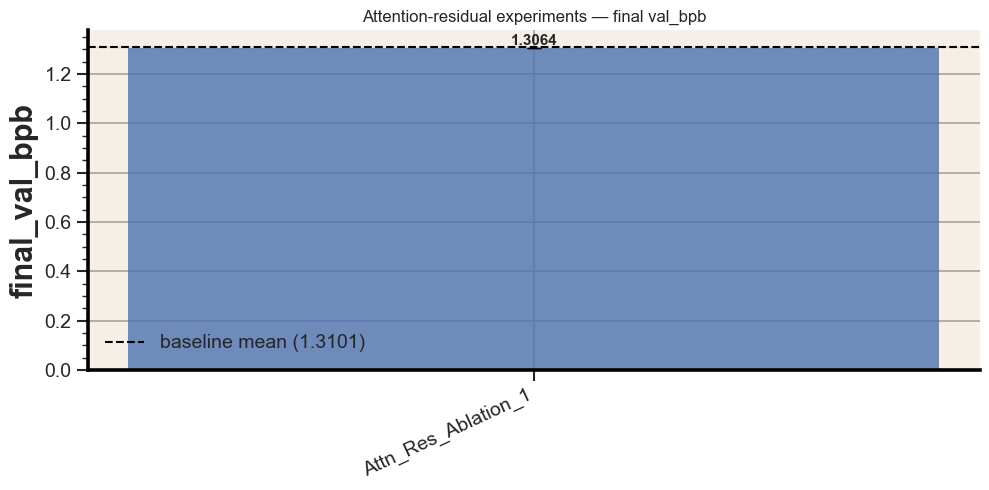

In [21]:
if not df_attn.empty:
    plot_df = (
        df_attn.groupby("group", dropna=False)["final_val_bpb"]
        .agg(["mean", "std", "count"])
        .sort_values("mean", ascending=True)
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    xs = np.arange(len(plot_df))
    ax.bar(xs, plot_df["mean"], color=PALETTE[0], alpha=0.8, zorder=2)
    std_vals = plot_df["std"].fillna(0).values
    ax.errorbar(xs, plot_df["mean"], yerr=std_vals, fmt="none", color="black", capsize=5, zorder=3)

    for i, row in plot_df.iterrows():
        ax.text(i, row["mean"] + 0.00025, f"{row['mean']:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

    if not np.isnan(BASE_BPB_MEAN):
        ax.axhline(BASE_BPB_MEAN, color="black", linewidth=1.5, linestyle="--", label=f"baseline mean ({BASE_BPB_MEAN:.4f})")
        if not np.isnan(BASE_BPB_STD):
            ax.axhspan(BASE_BPB_MEAN - BASE_BPB_STD, BASE_BPB_MEAN + BASE_BPB_STD, color="black", alpha=0.08)

    ax.set_xticks(xs)
    ax.set_xticklabels(plot_df["group"], rotation=25, ha="right")
    ax.set_ylabel("final_val_bpb")
    ax.set_title("Attention-residual experiments — final val_bpb")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No plot: no attention-residual runs.")

### Model size vs final val_bpb

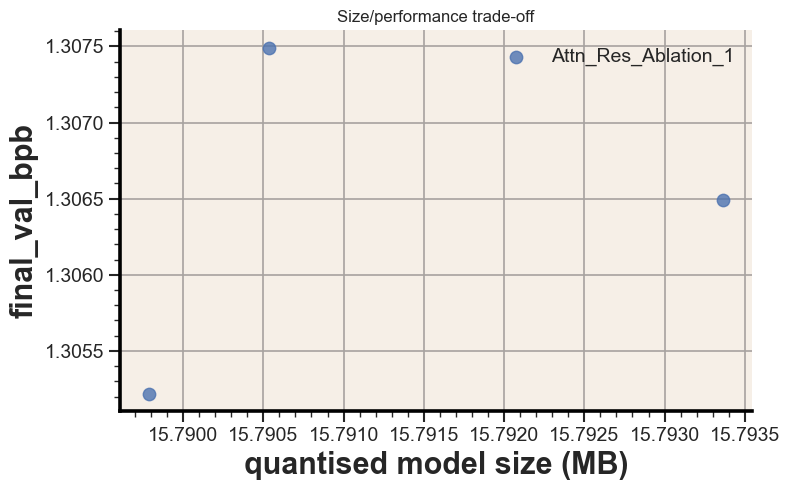

In [22]:
if not df_attn.empty and df_attn["quant_file_bytes"].notna().any():
    fig, ax = plt.subplots(figsize=(8, 5))
    for group, g in df_attn.groupby("group"):
        ax.scatter(g["quant_file_bytes"] / 1e6, g["final_val_bpb"], s=80, alpha=0.8, label=group)

    ax.set_xlabel("quantised model size (MB)")
    ax.set_ylabel("final_val_bpb")
    ax.set_title("Size/performance trade-off")
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()
else:
    print("No size/performance scatter available.")


## Learning curves

In [10]:
METRIC_KEYS = ["val_bpb", "val_loss", "train_loss", "lr_scale"]

attn_histories = {}
for run in attnres_runs:
    attn_histories[run.id] = fetch_history(run, METRIC_KEYS)

base_histories = {}
for run in baseline_runs:
    base_histories[run.id] = fetch_history(run, ["val_bpb", "val_loss", "train_loss"])

print(f"Histories fetched for attn-res runs: {sum(not h.empty for h in attn_histories.values())}")
print(f"Histories fetched for baseline runs : {sum(not h.empty for h in base_histories.values())}")

Histories fetched for attn-res runs: 3
Histories fetched for baseline runs : 3


In [11]:
def aggregate_histories(runs, history_map, metric):
    pieces = []
    for run in runs:
        hist = history_map.get(run.id, pd.DataFrame())
        if hist.empty or metric not in hist.columns:
            continue
        tmp = hist[["step", metric]].dropna().copy()
        tmp["group"] = strip_seed_suffix(run.display_name or run.name)
        tmp["seed"] = run.config.get("seed")
        pieces.append(tmp)
    if not pieces:
        return pd.DataFrame(columns=["group", "step", "mean", "std", "count"])
    long_df = pd.concat(pieces, ignore_index=True)
    out = (
        long_df.groupby(["group", "step"], dropna=False)[metric]
        .agg(["mean", "std", "count"])
        .reset_index()
        .sort_values(["group", "step"])
    )
    return out

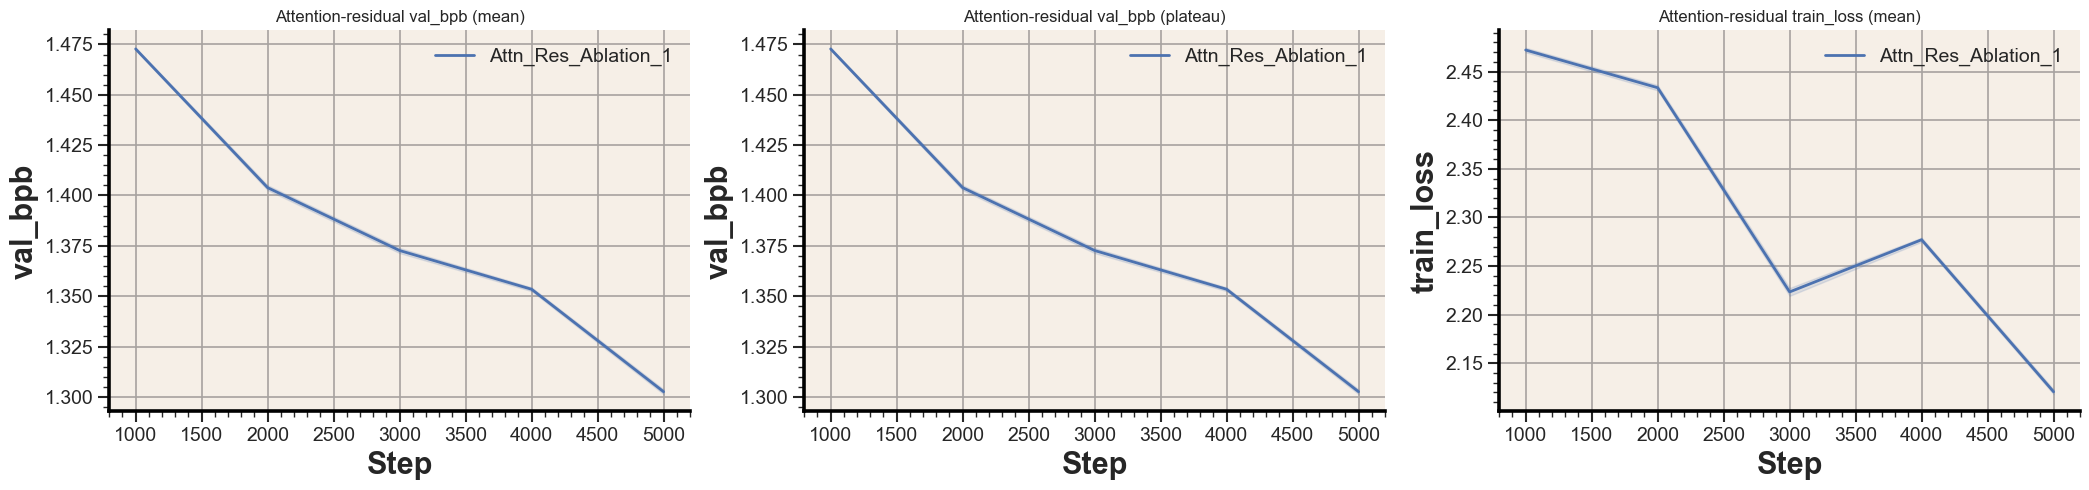

In [12]:
agg_val_bpb = aggregate_histories(attnres_runs, attn_histories, "val_bpb")
agg_train    = aggregate_histories(attnres_runs, attn_histories, "train_loss")

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# full val_bpb
ax = axes[0]
if not agg_val_bpb.empty:
    for i, (group, g) in enumerate(agg_val_bpb.groupby("group")):
        color = PALETTE[i % len(PALETTE)]
        ax.plot(g["step"], g["mean"], linewidth=2, color=color, label=group)
        if (g["count"] > 1).any():
            std = g["std"].fillna(0)
            ax.fill_between(g["step"], g["mean"] - std, g["mean"] + std, color=color, alpha=0.15)
ax.set_xlabel("Step")
ax.set_ylabel("val_bpb")
ax.set_title("Attention-residual val_bpb (mean)")
ax.legend()

# zoomed plateau
ax = axes[1]
ZOOM_STEP = 500
if not agg_val_bpb.empty:
    for i, (group, g) in enumerate(agg_val_bpb.groupby("group")):
        g = g[g["step"] >= ZOOM_STEP]
        color = PALETTE[i % len(PALETTE)]
        ax.plot(g["step"], g["mean"], linewidth=2, color=color, label=group)
        if (g["count"] > 1).any():
            std = g["std"].fillna(0)
            ax.fill_between(g["step"], g["mean"] - std, g["mean"] + std, color=color, alpha=0.15)
ax.set_xlabel("Step")
ax.set_ylabel("val_bpb")
ax.set_title("Attention-residual val_bpb (plateau)")
ax.legend()

# train loss
ax = axes[2]
if not agg_train.empty:
    for i, (group, g) in enumerate(agg_train.groupby("group")):
        color = PALETTE[i % len(PALETTE)]
        ax.plot(g["step"], g["mean"], linewidth=2, color=color, label=group)
        if (g["count"] > 1).any():
            std = g["std"].fillna(0)
            ax.fill_between(g["step"], g["mean"] - std, g["mean"] + std, color=color, alpha=0.15)
ax.set_xlabel("Step")
ax.set_ylabel("train_loss")
ax.set_title("Attention-residual train_loss (mean)")
ax.legend()

plt.tight_layout()
plt.show()

### Baseline vs best attention-residual group

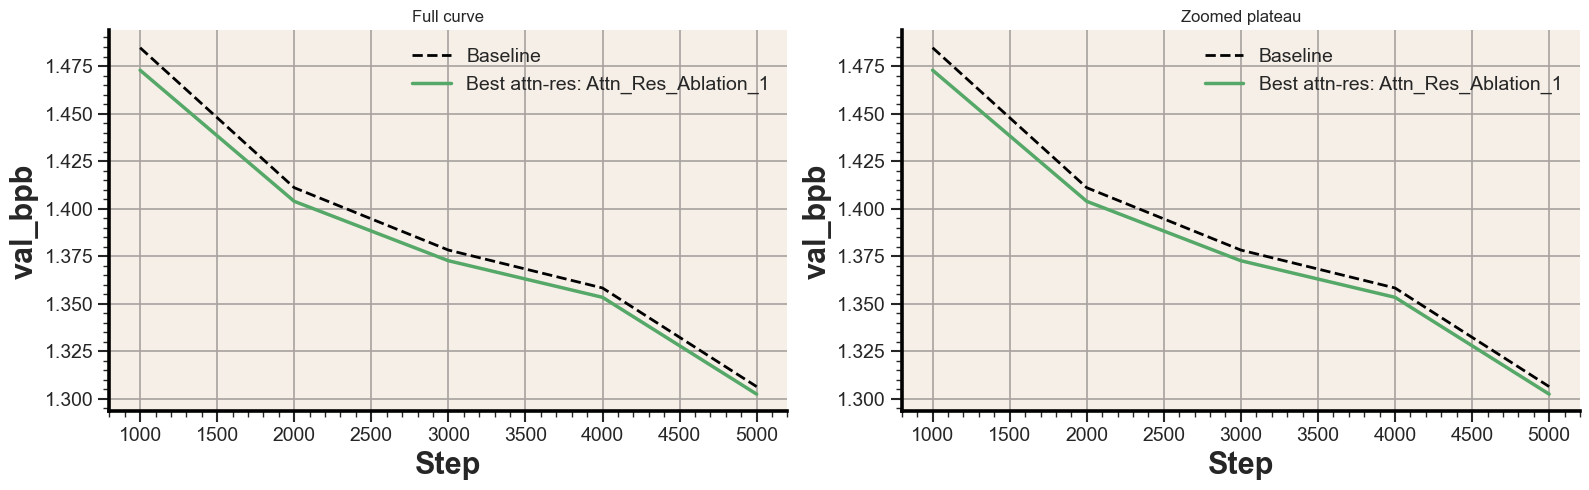

In [13]:
if not df_attn.empty and not df_base.empty and df_attn["final_val_bpb"].notna().any():
    best_group = (
        df_attn.groupby("group")["final_val_bpb"]
        .mean()
        .sort_values()
        .index[0]
    )

    best_runs = [r for r in attnres_runs if strip_seed_suffix(r.display_name or r.name) == best_group]
    best_hist = aggregate_histories(best_runs, attn_histories, "val_bpb")
    base_hist = aggregate_histories(baseline_runs, base_histories, "val_bpb")

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    for ax, zoom in zip(axes, [False, True]):
        h = base_hist.copy()
        b = best_hist.copy()
        if zoom:
            h = h[h["step"] >= 500]
            b = b[b["step"] >= 500]
        if not h.empty:
            g = h.groupby("step")[["mean", "std", "count"]].mean().reset_index()
            ax.plot(g["step"], g["mean"], color="black", linestyle="--", linewidth=2, label="Baseline")
        if not b.empty:
            g = b.groupby("step")[["mean", "std", "count"]].mean().reset_index()
            ax.plot(g["step"], g["mean"], color=PALETTE[2], linewidth=2.5, label=f"Best attn-res: {best_group}")
        ax.set_xlabel("Step")
        ax.set_ylabel("val_bpb")
        ax.set_title("Zoomed plateau" if zoom else "Full curve")
        ax.legend()

    plt.tight_layout()
    plt.show()
else:
    print("Need both baseline and attention-residual runs to make this comparison.")

## Efficiency and training-budget diagnostics

In [21]:
if not df_attn.empty:
    # Approximate budget-normalised view using config-level fields.
    eff = df_attn.copy()
    eff["tokens_target"] = eff["iterations"] * eff["train_batch_tokens"]
    eff["size_mb"] = eff["quant_file_bytes"] / 1e6

    cols = [
        "group", "seed", "iterations", "train_batch_tokens", "tokens_target",
        "max_wallclock_seconds", "size_mb", "final_val_bpb", "final_val_loss"
    ]
    display(eff[cols].sort_values(["group", "seed"], na_position="last"))
else:
    print("No efficiency table available.")


,group,seed,iterations,train_batch_tokens,tokens_target,max_wallclock_seconds,size_mb,final_val_bpb,final_val_loss
0,Andrea_Attn_Res,42,5000,131072,655360000,0,15.793365,1.306490,2.205954
1,Andrea_Attn_Res,123,5000,131072,655360000,0,15.790535,1.307492,2.207645
2,Andrea_Attn_Res,1337,5000,131072,655360000,0,15.789786,1.305216,2.203802


## Interpreting the current results

The current implementation changes only the **bridge between encoder and decoder halves** by replacing the scalar-weighted skip reuse with a softmax-weighted aggregation over stored encoder skip states plus the current decoder state. The rest of the transformer block stays the same as in the original script, including the standard residual updates inside each block. In the original training script, this bridge was a simple additive skip weighted by `skip_weights`; the patched variant swaps it for a learned attention-style residual module, but still logs the same top-level W&B metrics as before. fileciteturn1file1L655-L671

## Suggestions — what to try next

These suggestions are deliberately split into **high-value next ablations** and **instrumentation improvements**.

### 1) Zero-initialise the attention-residual query/projection
The paper explicitly says the pseudo-query vectors should start at zero so the initial source weights are uniform, which reduced training volatility in their experiments. If your current skip-attention module uses the default linear initialisation, this is one of the cleanest changes to try first. fileciteturn1file0L332-L336

### 2) Move closer to a paper-faithful residual replacement
Your current model only replaces the encoder/decoder skip bridge. The paper’s main gains come from replacing fixed residual accumulation **through depth inside the network**, not only from changing one long skip path. The most direct next step is to implement attention residuals inside the transformer residual stream, ideally first in a blockwise form. fileciteturn1file0L65-L85 fileciteturn1file0L139-L168

### 3) Sweep the number of attended skip sources or coarse block size
The paper reports that a small fixed number of blocks recovers most of the full-attention gain, while very coarse blocking trends back toward baseline. In your setting, the analogous experiment is to restrict the bridge attention to: only the most recent skip, last 2 skips, all skips, or grouped skip blocks. fileciteturn1file0L268-L286

### 4) Compare softmax attention against simpler alternatives
The paper found softmax better than sigmoid and input-independent mixing. In your codebase, a good controlled ablation is:
- scalar learned skip weights (old baseline)
- sigmoid gating over skips
- softmax over skips
This helps determine whether any gain comes from **competition between sources**, or simply from adding one more learned bridge. fileciteturn1file0L388-L399

### 5) Try an input-dependent query only if the basic version wins first
The paper reports that an input-dependent query can do better than the learned static query, but at higher cost. This is a sensible phase-2 experiment, not the first thing to optimise. fileciteturn1file0L388-L392

### 6) Run proper multi-seed comparisons before concluding anything
Because your script loops over multiple seeds and W&B already stores per-seed summaries, the most reliable signal is the mean and standard deviation across seeds for the same base run ID. Treat any single-seed gain as provisional until it survives a 3-seed rerun.

### 7) Check whether attention residuals prefer deeper/narrower settings in your code too
The paper’s architecture sweep suggests attention residuals benefit more from added depth under a fixed budget. A practical follow-up is a small grid over `(num_layers, model_dim)` at roughly matched parameter count or training budget. fileciteturn1file0L408-L423


## Instrumentation to add to W&B next time

The current analysis is limited because the script logs only global training metrics. To understand *why* an attention-residual variant helps or hurts, add these logs:

- mean attention weight assigned to each skip source
- entropy of the skip-source distribution
- fraction of mass on the current decoder state vs encoder skip states
- per-layer or per-block hidden-state norms
- gradient norms of the attention-residual parameters specifically
- zero-shot snapshots of the learned source-weight matrix over training

Those are the closest analogues of the paper’s weight-pattern and training-dynamics analysis, and they will make future notebooks much more informative. The paper attributes part of the benefit to bounded output magnitudes and more uniform gradient distribution, which you cannot verify yet with the present logging. fileciteturn1file0L299-L316 fileciteturn1file0L425-L443

## Optional: quick experiment shortlist

If you want the next three experiments to be the most informative per unit effort, I would do them in this order:

1. **Zero-init query/projection + 3 seeds**  
2. **Softmax vs sigmoid vs old scalar skip bridge**  
3. **Bridge-only attention residual vs true in-block residual replacement**

That sequence tells you whether the current implementation is underperforming because of bad initialisation, because the bridge mechanism itself is not the right place to apply attention residuals, or because the paper’s gains only appear once the full residual path is replaced.
